In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [3]:
# ── Load Data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("https://drive.google.com/uc?id=1Nc2I524NvB4xs6ywnsGt76M0YDOZmjbb")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"\nTarget stats (RUL):")
print(df["RUL"].describe().to_string())

Shape: (30631, 15)
Columns: ['Source', 'Air_Temperature', 'Process_Temp', 'Rotational_Speed', 'Torque', 'Life_Consumed', 'Stress_Index', 'RUL', 'Is_Failure', 'Health_Status', 'PC1', 'PC2', 'PC3', 'Cluster', 'Health_Regime']
Null values: 0

Target stats (RUL):
count    30631.000000
mean        84.829944
std         68.860316
min          0.000000
25%         27.000000
50%         68.000000
75%        132.000000
max        361.000000


In [4]:
# ── Features + Target ──────────────────────────────────────────────────────────
# PC1–PC3: compressed sensor data via PCA — no raw sensors needed
# Cluster, Stress_Index: operational context features
# Health_Status / Is_Failure excluded — derived from RUL (data leakage)
FEATURES = ["PC1", "PC2", "PC3", "Cluster", "Stress_Index"]
TARGET   = "RUL"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"\nFeatures used: {FEATURES}")
print(f"Target: {TARGET}")
print(f"X shape: {X.shape}")


Features used: ['PC1', 'PC2', 'PC3', 'Cluster', 'Stress_Index']
Target: RUL
X shape: (30631, 5)


In [5]:
# ── Train / Test Split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test  size: {X_test.shape[0]}")


Train size: 24504
Test  size: 6127


In [6]:
# ── XGBRegressor ───────────────────────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
    early_stopping_rounds = 20
)

xgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_test, y_test)],
    verbose   = False
)

y_pred_xgb = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2   = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost  |  RMSE: {xgb_rmse:.4f}  |  MAE: {xgb_mae:.4f}  |  R²: {xgb_r2:.4f}")


XGBoost  |  RMSE: 40.2242  |  MAE: 28.7548  |  R²: 0.6601


In [10]:
# ── Cross Validation — XGBoost ─────────────────────────────────────────────────
kf      = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv  = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    m = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, n_jobs=-1, verbosity=0)
    m.fit(X_tr, y_tr)
    xgb_cv.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))

xgb_cv = np.array(xgb_cv)
print(f"XGBoost CV RMSE : {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f} | Folds: {np.round(xgb_cv, 4)}")

XGBoost CV RMSE : 40.7006 ± 0.3112 | Folds: [41.1174 40.344  40.3382 40.7963 40.9072]


In [8]:
# ── Second Model: Random Forest ────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print(f"RandForest  |  RMSE: {rf_rmse:.4f}  |  MAE: {rf_mae:.4f}  |  R²: {rf_r2:.4f}")

RandForest  |  RMSE: 40.2149  |  MAE: 28.7521  |  R²: 0.6603


In [9]:
# ── Cross Validation — Random Forest ──────────────────────────────────────────
rf_cv = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    m = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    rf_cv.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))

rf_cv = np.array(rf_cv)
print(f"RandForest CV RMSE : {rf_cv.mean():.4f} ± {rf_cv.std():.4f} | Folds: {np.round(rf_cv, 4)}")

RandForest CV RMSE : 39.8764 ± 0.2512 | Folds: [40.2258 39.6055 39.5928 39.8823 40.0753]


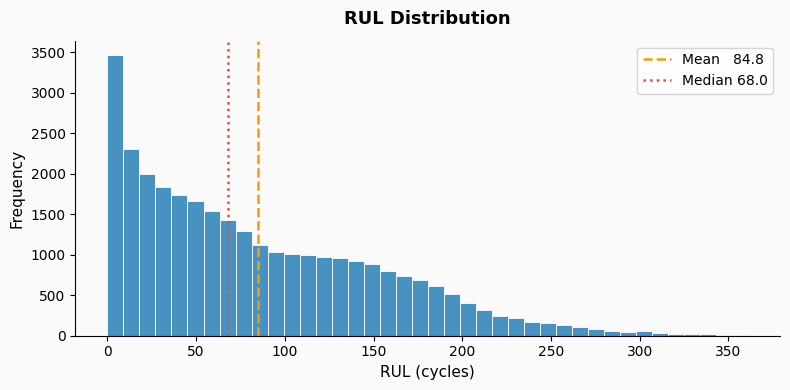

In [12]:
# ── Plot Styling ───────────────────────────────────────────────────────────────
fig_bg = "#FAFAFA"

# ── Plot 1: RUL Distribution ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), facecolor=fig_bg)
ax.hist(y, bins=40, color="#2980b9", edgecolor="white", linewidth=0.7, alpha=0.85)
ax.axvline(y.mean(),   color="#f39c12", lw=1.8, linestyle="--", label=f"Mean   {y.mean():.1f}")
ax.axvline(y.median(), color="#e74c3c", lw=1.8, linestyle=":",  label=f"Median {y.median():.1f}")

ax.set_title("RUL Distribution", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("RUL (cycles)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("01_rul_distribution.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

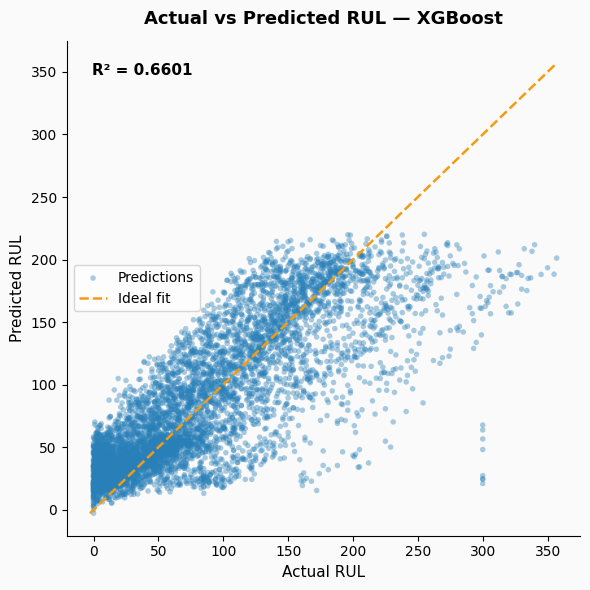

In [14]:
# ── Plot 2: Actual vs Predicted ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6), facecolor=fig_bg)

ax.scatter(y_test, y_pred_xgb, alpha=0.4, s=16,
           color="#2980b9", edgecolors="none", label="Predictions")

lims = [min(y_test.min(), y_pred_xgb.min()),
        max(y_test.max(), y_pred_xgb.max())]

ax.plot(lims, lims, "--", color="#f39c12", lw=1.8, label="Ideal fit")

ax.set_title("Actual vs Predicted RUL — XGBoost",
             fontsize=13, fontweight="bold", pad=12)

ax.set_xlabel("Actual RUL", fontsize=11)
ax.set_ylabel("Predicted RUL", fontsize=11)

ax.text(0.05, 0.93, f"R² = {xgb_r2:.4f}",
        transform=ax.transAxes, fontsize=11, fontweight="bold")

ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("02_actual_vs_predicted.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

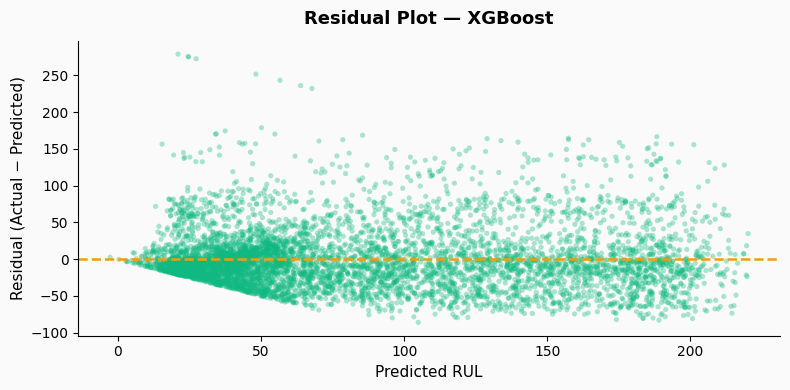

In [16]:
# ── Plot 3: Residual Plot ──────────────────────────────────────────────────────
residuals = y_test.values - y_pred_xgb

fig, ax = plt.subplots(figsize=(8, 4), facecolor=fig_bg)
ax.scatter(y_pred_xgb, residuals, alpha=0.35, s=14,
           color="#10b981", edgecolors="none")

ax.axhline(0, color="#f39c12", lw=1.8, linestyle="--")

ax.set_title("Residual Plot — XGBoost",
             fontsize=13, fontweight="bold", pad=12)

ax.set_xlabel("Predicted RUL", fontsize=11)
ax.set_ylabel("Residual (Actual − Predicted)", fontsize=11)

ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("03_residual_plot.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

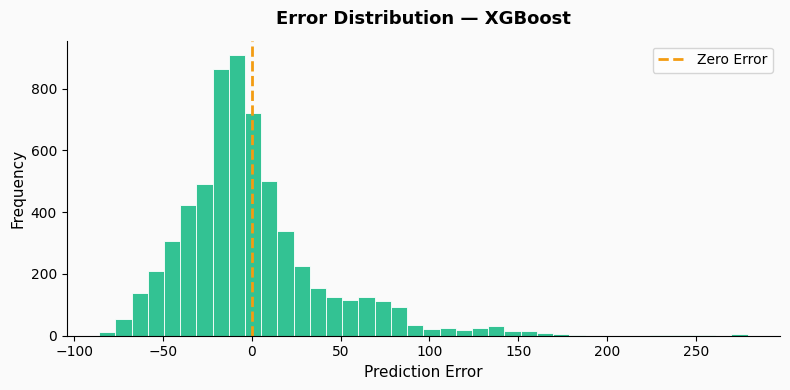

In [18]:
# ── Plot 4: Error Distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), facecolor=fig_bg)

ax.hist(residuals, bins=40, color="#10b981",
        edgecolor="white", linewidth=0.7, alpha=0.85)

ax.axvline(0, color="#f39c12", lw=2,
           linestyle="--", label="Zero Error")

ax.set_title("Error Distribution — XGBoost",
             fontsize=13, fontweight="bold", pad=12)

ax.set_xlabel("Prediction Error", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("04_error_distribution.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

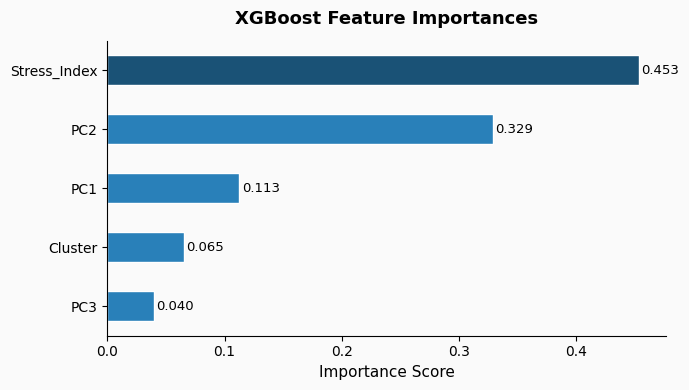

In [20]:
# ── Plot 5: Feature Importance ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4), facecolor=fig_bg)

importances = pd.Series(
    xgb_model.feature_importances_, index=FEATURES
).sort_values()

colors = ["#2980b9" if v < importances.max() else "#1a5276"
          for v in importances]

importances.plot(kind="barh", ax=ax, color=colors, edgecolor="white")

ax.set_title("XGBoost Feature Importances",
             fontsize=13, fontweight="bold", pad=12)

ax.set_xlabel("Importance Score", fontsize=11)

ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f"{v:.3f}",
            va="center", fontsize=9.5)

plt.tight_layout()
plt.savefig("05_feature_importance.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

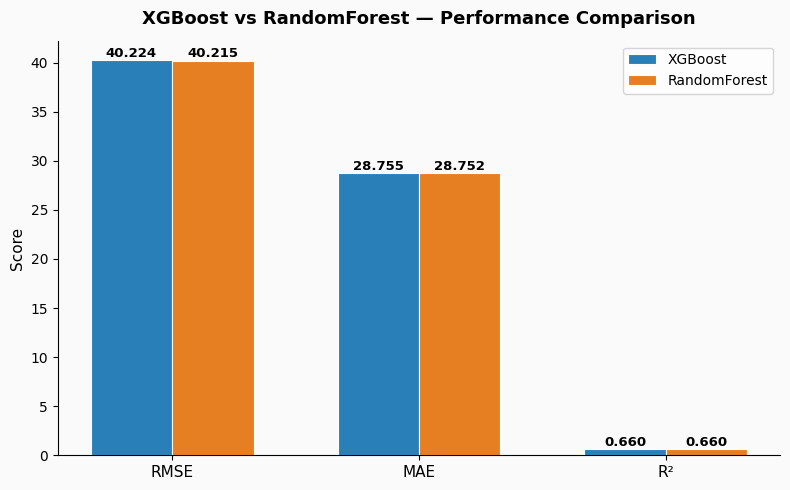

In [22]:
# ── Plot 6: Model Comparison ───────────────────────────────────────────────────
metrics    = ["RMSE", "MAE", "R²"]
xgb_scores = [xgb_rmse, xgb_mae, xgb_r2]
rf_scores  = [rf_rmse,  rf_mae,  rf_r2]

x = np.arange(len(metrics))
w = 0.33

fig, ax = plt.subplots(figsize=(8, 5), facecolor=fig_bg)

b1 = ax.bar(x - w/2, xgb_scores, width=w,
            label="XGBoost", color="#2980b9",
            edgecolor="white", linewidth=0.8)

b2 = ax.bar(x + w/2, rf_scores, width=w,
            label="RandomForest", color="#e67e22",
            edgecolor="white", linewidth=0.8)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f"{h:.3f}", ha="center", va="bottom",
                fontsize=9.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)

ax.set_title("XGBoost vs RandomForest — Performance Comparison",
             fontsize=13, fontweight="bold", pad=12)

ax.set_ylabel("Score", fontsize=11)

ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("06_model_comparison.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

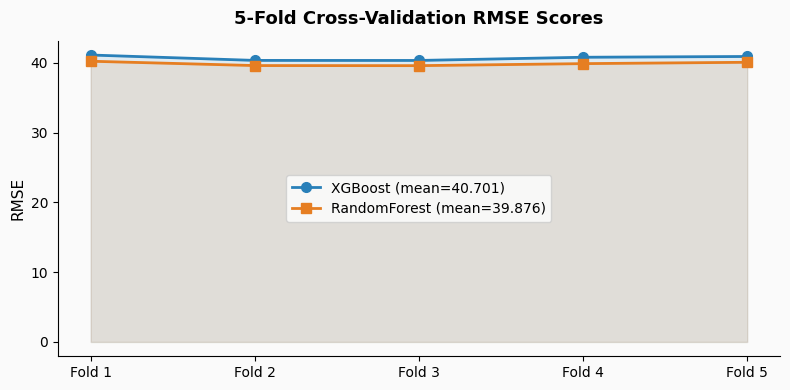

In [24]:
# ── Plot 7: CV Scores ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), facecolor=fig_bg)

fold_labels = [f"Fold {i+1}" for i in range(5)]
x = np.arange(5)

ax.plot(x, xgb_cv, "o-", color="#2980b9",
        linewidth=2, markersize=7,
        label=f"XGBoost (mean={xgb_cv.mean():.3f})")

ax.plot(x, rf_cv, "s-", color="#e67e22",
        linewidth=2, markersize=7,
        label=f"RandomForest (mean={rf_cv.mean():.3f})")

ax.fill_between(x, xgb_cv, alpha=0.12, color="#2980b9")
ax.fill_between(x, rf_cv,  alpha=0.12, color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(fold_labels)

ax.set_ylabel("RMSE", fontsize=11)

ax.set_title("5-Fold Cross-Validation RMSE Scores",
             fontsize=13, fontweight="bold", pad=12)

ax.legend(fontsize=10)
ax.set_facecolor(fig_bg)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("07_cv_scores.png", dpi=150, bbox_inches="tight")  # fixed
plt.show()

In [26]:
# ── Save Models ────────────────────────────────────────────────────────────────
import pickle

with open("xgb_regressor.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

with open("second_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Saved: xgb_regressor.pkl")
print("Saved: second_model.pkl")

Saved: xgb_regressor.pkl
Saved: second_model.pkl


In [27]:
# ── Final Summary ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    "Model"   : ["XGBoost", "RandomForest"],
    "RMSE"    : [round(xgb_rmse, 4), round(rf_rmse, 4)],
    "MAE"     : [round(xgb_mae,  4), round(rf_mae,  4)],
    "R²"      : [round(xgb_r2,   4), round(rf_r2,   4)],
    "CV Mean" : [round(xgb_cv.mean(), 4), round(rf_cv.mean(), 4)],
    "CV Std"  : [round(xgb_cv.std(),  4), round(rf_cv.std(),  4)],
})
print(summary.to_string(index=False))

winner = "XGBoost" if xgb_rmse <= rf_rmse else "RandomForest"
print(f"\n  Best model by RMSE: {winner}")
print("=" * 60)


  FINAL RESULTS SUMMARY
       Model    RMSE     MAE     R²  CV Mean  CV Std
     XGBoost 40.2242 28.7548 0.6601  40.7006  0.3112
RandomForest 40.2149 28.7521 0.6603  39.8764  0.2512

  Best model by RMSE: RandomForest
